# Лабораторная работа 1

1) Классификация данных методом k ближайших соседей ( kNN)

2) Классификация данных методом опорных векторов (SVM)

3) Построение softmax-классификатора

Вариант 1: задания 1 и 2 на наборе данных CIFAR-10

Вариант 2: задания 1 и 2 на наборе данных MNIST

Вариант 3: задания 1 и 3 на наборе данных CIFAR-10

Вариант 4: задания 1 и 3 на наборе данных MNIST

Лабораторные работы можно выполнять с использованием сервиса Google Colaboratory (https://medium.com/deep-learning-turkey/google-colab-free-gpu-tutorial-e113627b9f5d) или на локальном компьютере. 

## 1. Классификация данных методом k ближайших соседей ( kNN)

In [27]:
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split


%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'
np.random.seed(42)
random.seed(42)

1.1 Скачайте данные в соответсвии с заданием.

CIFAR-10 по ссылке https://www.cs.toronto.edu/~kriz/cifar.html
или используйте  команду !bash get_datasets.sh (google colab, local ubuntu)

MNIST 
sklearn.datasets import load_digits
digits = load_digits()

In [28]:
digits = load_digits()
X = digits.images
y = digits.target
class_names = digits.target_names

print('Images shape:', X.shape)
print('Labels shape:', y.shape)
print('Classes:', class_names)

Images shape: (1797, 8, 8)
Labels shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]


In [29]:
print('Image size:', X.shape[1:])
print('Number of classes:', len(class_names))

Image size: (8, 8)
Number of classes: 10


1.2 Выведите несколько примеров изображений из обучающей выборки для каждого класса.



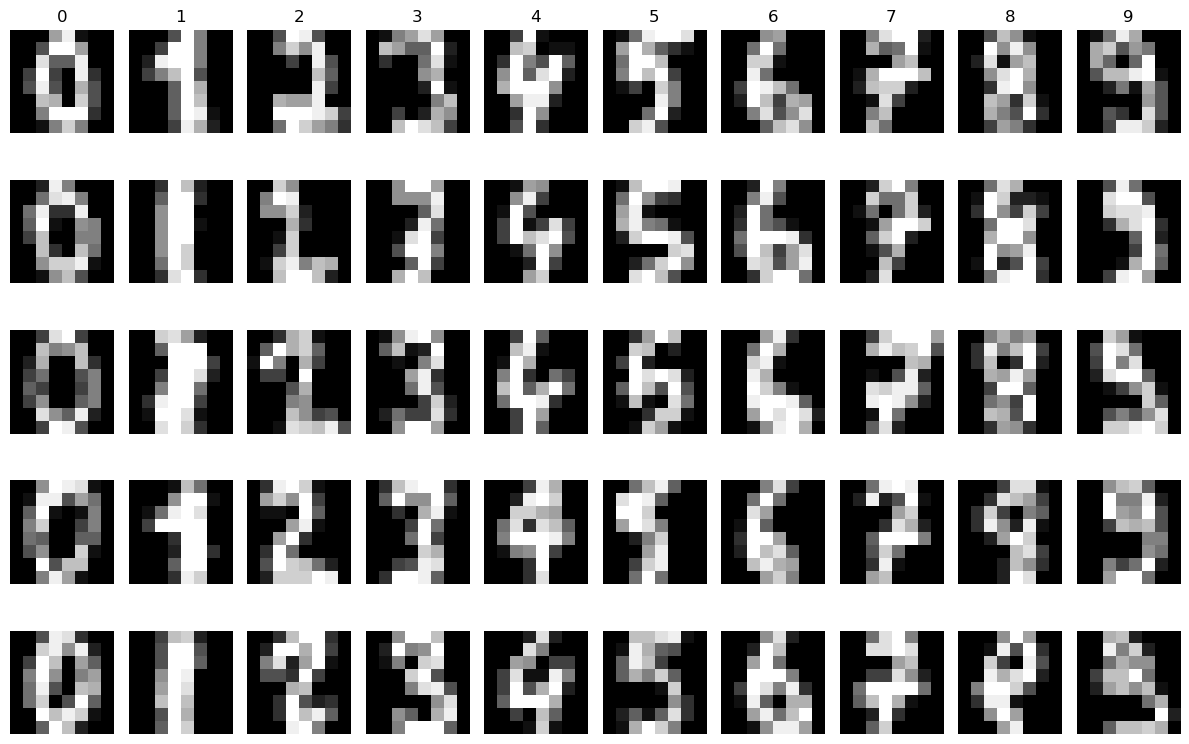

In [30]:
samples_per_class = 5
plt.figure(figsize=(12, 8))
for cls, class_name in enumerate(class_names):
    idxs = np.flatnonzero(y == cls)
    idxs = np.random.choice(idxs, samples_per_class, replace=False)
    for i, idx in enumerate(idxs):
        plt_idx = i * len(class_names) + cls + 1
        plt.subplot(samples_per_class, len(class_names), plt_idx)
        plt.imshow(X[idx], cmap='gray')
        plt.axis('off')
        if i == 0:
            plt.title(str(class_name))
plt.tight_layout()
plt.show()

1.3 Разделите данные на обучающу и тестовую выборки (X_train, y_train, X_test, y_test). Преобразуйте каждое изображение в одномерный массив. 

In [31]:
X_flat = X.reshape(X.shape[0], -1).astype(np.float64)
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.25, random_state=42, stratify=y
)

print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (1347, 64)
Training labels shape:  (1347,)
Test data shape:  (450, 64)
Test labels shape:  (450,)


1.4 Напишите реализацию классификатора в скрипте /classifiers/k_nearest_neighbor.py и обучите его на сформированной выборке. 

In [32]:
from scripts.classifiers import KNearestNeighbor

classifier = KNearestNeighbor()
classifier.train(X_train, y_train)

1.5 Выполните классификацию на тестовой выборке

In [33]:
k = 1
y_test_pred = classifier.predict(X_test, k=k, num_loops=0)
num_correct = np.sum(y_test_pred == y_test)
print('Correct predictions:', num_correct)
print('Total predictions:', y_test.shape[0])

Correct predictions: 443
Total predictions: 450


1.6 Визуализируйте матрицу расстояний для каждого изображения из тестовой выборки до изображений из обучающей выборки. 


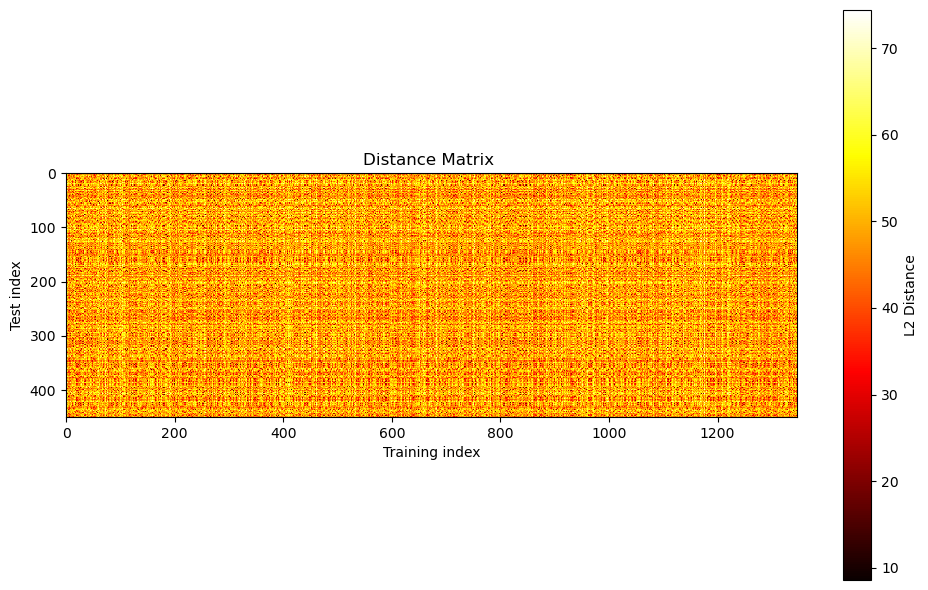

In [34]:
dists = classifier.compute_distances_no_loops(X_test)
plt.figure(figsize=(10, 6))
plt.imshow(dists, cmap='hot', interpolation='nearest')
plt.xlabel('Training index')
plt.ylabel('Test index')
plt.title('Distance Matrix ')
plt.colorbar(label='L2 Distance')
plt.tight_layout()
plt.show()


1.7 Посчитайте долю правильно классифицированных изображений из тестовой выборки.


In [35]:
accuracy = np.mean(y_test_pred == y_test)
print('Accuracy:', accuracy)

Accuracy: 0.9844444444444445


1.8 Постройте график зависимости доли правильно классифицированных изображений от числа соседей, используемых при классификации.

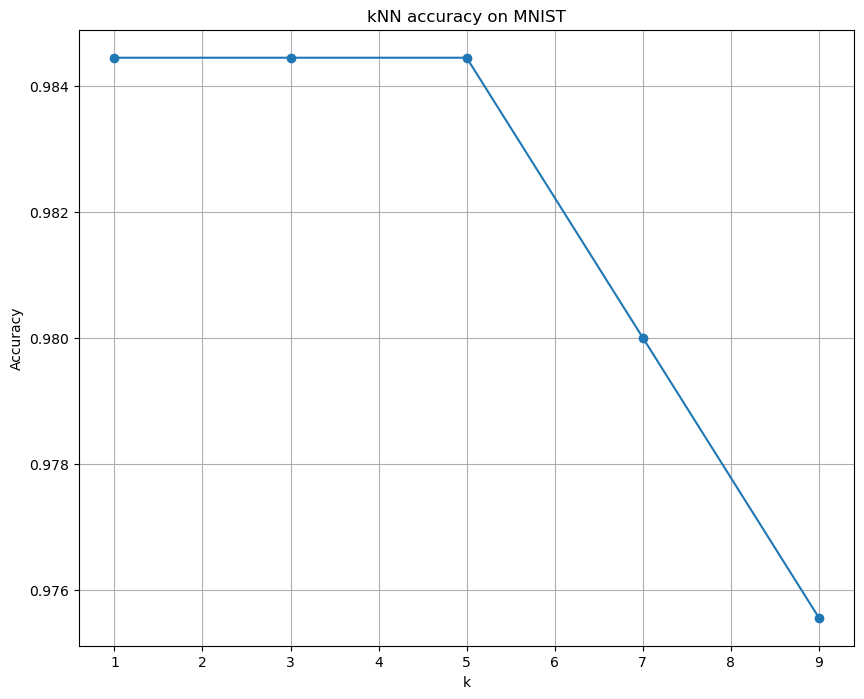

k=1: 0.9844
k=3: 0.9844
k=5: 0.9844
k=7: 0.9800
k=9: 0.9756


In [36]:
k_choices = [1, 3, 5, 7, 9]
k_accuracies = []

for k in k_choices:
    y_test_pred = classifier.predict(X_test, k=k, num_loops=0)
    k_accuracies.append(np.mean(y_test_pred == y_test))

plt.plot(k_choices, k_accuracies, marker='o')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.title('kNN accuracy on MNIST')
plt.grid(True)
plt.show()

for k, acc in zip(k_choices, k_accuracies):
    print(f'k={k}: {acc:.4f}')

1.9 Выберите лучшее значение параметра k на основе кросс-валидации.


In [37]:
num_folds = 5
k_choices = [1, 3, 5, 7, 9]
X_train_folds = np.array_split(X_train, num_folds)
y_train_folds = np.array_split(y_train, num_folds)
k_to_accuracies = {}

for k in k_choices:
    fold_accuracies = []
    for fold in range(num_folds):
        X_val_fold = X_train_folds[fold]
        y_val_fold = y_train_folds[fold]
        X_train_fold = np.vstack([X_train_folds[i] for i in range(num_folds) if i != fold])
        y_train_fold = np.hstack([y_train_folds[i] for i in range(num_folds) if i != fold])

        fold_classifier = KNearestNeighbor()
        fold_classifier.train(X_train_fold, y_train_fold)
        y_val_pred = fold_classifier.predict(X_val_fold, k=k, num_loops=0)
        fold_accuracies.append(np.mean(y_val_pred == y_val_fold))

    k_to_accuracies[k] = fold_accuracies

for k in sorted(k_to_accuracies):
    print(k, k_to_accuracies[k], np.mean(k_to_accuracies[k]))

best_k = max(k_choices, key=lambda k: (np.mean(k_to_accuracies[k]), -k))
print('Best k:', best_k)

1 [np.float64(0.9962962962962963), np.float64(0.9814814814814815), np.float64(0.9925650557620818), np.float64(0.9888475836431226), np.float64(0.9925650557620818)] 0.9903510945890128
3 [np.float64(0.9888888888888889), np.float64(0.9777777777777777), np.float64(0.9925650557620818), np.float64(0.9888475836431226), np.float64(0.9851301115241635)] 0.986641883519207
5 [np.float64(0.9888888888888889), np.float64(0.9777777777777777), np.float64(0.9814126394052045), np.float64(0.9888475836431226), np.float64(0.9888475836431226)] 0.9851548946716233
7 [np.float64(0.9851851851851852), np.float64(0.9666666666666667), np.float64(0.9851301115241635), np.float64(0.9851301115241635), np.float64(0.9925650557620818)] 0.9829354261324521
9 [np.float64(0.9851851851851852), np.float64(0.9703703703703703), np.float64(0.9814126394052045), np.float64(0.9814126394052045), np.float64(0.9888475836431226)] 0.9814456836018174
Best k: 1



1.10 Переобучите и протестируйте классификатор с использованием выбранного значения k.



In [38]:
classifier = KNearestNeighbor()
classifier.train(X_train, y_train)
y_test_pred = classifier.predict(X_test, k=best_k, num_loops=0)
final_accuracy = np.mean(y_test_pred == y_test)
print('Best k:', best_k)
print('Test accuracy:', final_accuracy)

Best k: 1
Test accuracy: 0.9844444444444445


1.11 Сделайте выводы по результатам 1 части задания.

В ходе выполнения 1 части задания был реализован и протестирован kNN-классификатор на наборе данных MNIST. После разбиения данных на обучающую и тестовую выборки классификатор показал высокое качество: при k = 1 было правильно распознано 443 из 450 изображений, что соответствует accuracy 0.9844. Сравнение разных значений k показало, что на тестовой выборке наилучший результат дали k = 1, k = 3 и k = 5, однако по кросс-валидации лучшим оказалось значение k = 1 со средней точностью 0.99035. Это показывает, что для данного набора данных метод ближайших соседей работает очень эффективно, а подбор параметра k с помощью кросс-валидации позволяет обоснованно выбрать наиболее удачную конфигурацию.

## 3.  Построение softmax-классификатора

3.1 Разделите данные на обучающую, тестовую и валидационную выборки. Преобразуйте каждое изображение в одномерный массив. Выведите размеры выборок.

In [40]:
X_flat = X.reshape(X.shape[0], -1).astype(np.float64)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)
num_dev = min(200, X_train.shape[0])
mask = np.random.choice(X_train.shape[0], num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('Dev data shape: ', X_dev.shape)
print('Dev labels shape: ', y_dev.shape)

Train data shape:  (1149, 64)
Train labels shape:  (1149,)
Validation data shape:  (288, 64)
Validation labels shape:  (288,)
Test data shape:  (360, 64)
Test labels shape:  (360,)
Dev data shape:  (200, 64)
Dev labels shape:  (200,)


3.2 Проведите предварительную обработку данных, путем вычитания среднего изображения, рассчитанного  по обучающей выборке.

3.3 Чтобы далее не учитывать смещение (свободный член b), добавьте дополнитульную размерность к массиву данных и заполните ее единицами.

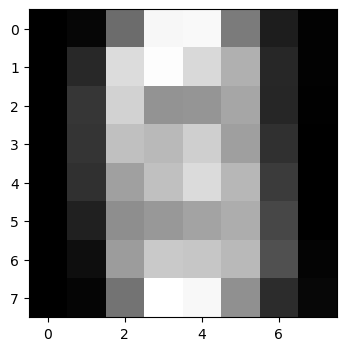

(1149, 65) (288, 65) (360, 65) (200, 65)


In [41]:
mean_image = np.mean(X_train, axis=0)
plt.figure(figsize=(4, 4))
plt.imshow(mean_image.reshape((8, 8)), cmap='gray')
plt.show()

X_train = X_train - mean_image
X_val = X_val - mean_image
X_test = X_test - mean_image
X_dev = X_dev - mean_image

X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

3.4 Реализуйте функции в classifiers/softmax.py




In [42]:
from scripts.classifiers.softmax import softmax_loss_naive
import time

W = np.random.randn(X_train.shape[1], 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.301998
sanity check: 2.302585


3.5 Убедитесь, что вы верно реализовали расчет градиента, сравнив с реализацией численными методами (код приведен ниже).

In [43]:
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)


from scripts.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)


loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: 0.129811 analytic: 0.129811, relative error: 4.168319e-10
numerical: 0.391695 analytic: 0.391695, relative error: 2.364443e-10
numerical: -0.196118 analytic: -0.196118, relative error: 1.927831e-10
numerical: -0.399445 analytic: -0.399445, relative error: 1.614190e-10
numerical: 0.249049 analytic: 0.249049, relative error: 1.154692e-10
numerical: 0.159478 analytic: 0.159478, relative error: 4.056755e-10
numerical: 0.442158 analytic: 0.442158, relative error: 1.467449e-10
numerical: 0.057611 analytic: 0.057611, relative error: 7.707609e-10
numerical: 0.005006 analytic: 0.005006, relative error: 6.558418e-09
numerical: 0.038155 analytic: 0.038155, relative error: 3.268832e-11
numerical: 0.137136 analytic: 0.137136, relative error: 1.383022e-10
numerical: -0.227195 analytic: -0.227195, relative error: 1.740306e-10
numerical: -0.021146 analytic: -0.021146, relative error: 9.689157e-10
numerical: 0.720307 analytic: 0.720307, relative error: 6.866243e-11
numerical: 0.609018 analyt

3.6 Сравните softmax_loss_naive и softmax_loss_vectorized реализации

In [44]:
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from scripts.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))


grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.301998e+00 computed in 0.022788s
vectorized loss: 2.301998e+00 computed in 0.002671s
Loss difference: 0.000000
Gradient difference: 0.000000


3.7 Реализуйте стохастический градиентный спуск в /classifiers/linear_classifier.py . Реализуйте методы train() и predict() и запустите следующий код

3.8 Обучите Softmax-классификатор и оцените accuracy на тестовой выборке.

3.9 С помощью кросс-валидации выберите значения параметров скорости обучения и регуляризации. В кросс-валидации используйте обучающую и валидационную выборки. Оцените accuracy на тестовой выборке.

In [45]:
from scripts.classifiers import Softmax

results = {}
best_val = -1
best_softmax = None
learning_rates = [1e-3, 5e-3, 1e-2]
regularization_strengths = [1e-5, 1e-4, 1e-3]

for learning_rate in learning_rates:
    for reg in regularization_strengths:
        softmax = Softmax()
        softmax.train(
            X_train,
            y_train,
            learning_rate=learning_rate,
            reg=reg,
            num_iters=1500,
            batch_size=200,
            verbose=False,
        )
        train_accuracy = np.mean(softmax.predict(X_train) == y_train)
        val_accuracy = np.mean(softmax.predict(X_val) == y_val)
        results[(learning_rate, reg)] = (train_accuracy, val_accuracy)
        if val_accuracy > best_val:
            best_val = val_accuracy
            best_softmax = softmax

for (learning_rate, reg), (train_accuracy, val_accuracy) in sorted(results.items()):
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (learning_rate, reg, train_accuracy, val_accuracy))

print('best validation accuracy: %f' % best_val)
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test_pred == y_test)
print('test accuracy: %f' % test_accuracy)

lr 1.000000e-03 reg 1.000000e-05 train accuracy: 0.973020 val accuracy: 0.972222
lr 1.000000e-03 reg 1.000000e-04 train accuracy: 0.973020 val accuracy: 0.968750
lr 1.000000e-03 reg 1.000000e-03 train accuracy: 0.975631 val accuracy: 0.972222
lr 5.000000e-03 reg 1.000000e-05 train accuracy: 0.993037 val accuracy: 0.975694
lr 5.000000e-03 reg 1.000000e-04 train accuracy: 0.992167 val accuracy: 0.972222
lr 5.000000e-03 reg 1.000000e-03 train accuracy: 0.993037 val accuracy: 0.975694
lr 1.000000e-02 reg 1.000000e-05 train accuracy: 0.998259 val accuracy: 0.972222
lr 1.000000e-02 reg 1.000000e-04 train accuracy: 0.998259 val accuracy: 0.975694
lr 1.000000e-02 reg 1.000000e-03 train accuracy: 0.998259 val accuracy: 0.972222
best validation accuracy: 0.975694
test accuracy: 0.958333


3.10 Сделайте выводы по третьей части задания

В 3 части задания был реализован softmax-классификатор и стохастический градиентный спуск для его обучения. Проверка градиента показала очень малые значения относительной ошибки, что подтверждает корректность реализации функции потерь и её производных. Также значения loss для наивной и векторизованной реализаций совпали, а векторизованная версия работала заметно быстрее. При подборе гиперпараметров лучшая модель показала точность 0.975694 на валидационной выборке и 0.958333 на тестовой. Это говорит о том, что softmax-классификатор хорошо решает задачу распознавания цифр на MNIST, хотя по качеству немного уступает kNN в рамках данного эксперимента. При этом softmax-модель является более универсальным и масштабируемым подходом, особенно для дальнейшего перехода к более сложным моделям машинного обучения.